# Mobility & Economy: Urban Traffic and Economic Indicators in Latin America

## Project Overview

This project explores the relationship between urban traffic congestion and socioeconomic conditions across major Latin American cities.

The analysis combines more than one million traffic observations from TomTom with city-level economic and demographic indicators. The workflow includes data cleaning, transformation, annual city-level aggregation, integration of heterogeneous sources, exploratory analysis, and visualization.

The objective is to identify urban mobility patterns and examine whether congestion levels appear to be associated with indicators such as GDP per capita, unemployment, air pollution, and population.

> **Analytical scope:** This is an exploratory observational analysis. Associations are described as patterns in the available data and should not be interpreted as causal effects.

## 1. Setup and Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

traffic = pd.read_csv("tomtom_traffic.csv")
eco = pd.read_csv("oecd_city_economy.csv")

print(f"Traffic observations: {len(traffic):,}")
print(f"Traffic cities: {traffic['City'].nunique():,}")
print(f"Traffic countries: {traffic['Country'].nunique():,}")
display(traffic.head())
display(eco.head())

Traffic observations: 1,004,464
Traffic cities: 384
Traffic countries: 55


,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


## 2. Data Cleaning and Preparation

Column names are standardized, date fields are converted safely, and numeric fields from the economic dataset are normalized before analysis.

In [4]:
traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_hist_per_10kms_mins',
    'MinsDelay': 'mins_delay'
})

eco = eco.rename(columns={
    'Year': 'year',
    'City': 'city',
    'Country': 'country_name',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_pct',
    'PM2.5 (μg/m³)': 'pm25',
    'Population (M)': 'population_m'
})

traffic['update_time_utc'] = pd.to_datetime(
    traffic['update_time_utc'], errors='coerce'
)
traffic['update_time_utc_week_ago'] = pd.to_datetime(
    traffic['update_time_utc_week_ago'], errors='coerce'
)

eco['city_gdp_capita'] = (
    eco['city_gdp_capita'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

eco['unemployment_pct'] = (
    eco['unemployment_pct'].astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

eco['pm25'] = (
    eco['pm25'].astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Population is expressed in millions. Decimal commas must become decimal points.
eco['population_m'] = (
    eco['population_m'].astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)
eco['population'] = eco['population_m'] * 1_000_000

# TomTom uses ISO-3 country codes while the economic dataset uses country names.
country_to_iso3 = {
    'Argentina': 'ARG',
    'Brazil': 'BRA',
    'Chile': 'CHL',
    'Colombia': 'COL',
    'Mexico': 'MEX',
    'Peru': 'PER',
    'Uruguay': 'URY'
}
eco['country'] = eco['country_name'].map(country_to_iso3)

print("Invalid dates after conversion:")
print(traffic[['update_time_utc', 'update_time_utc_week_ago']].isna().sum())

print("\nUnmapped economic countries:")
print(eco.loc[eco['country'].isna(), 'country_name'].unique())

print("\nEconomic data types:")
print(eco.dtypes)

display(eco.head())


Invalid dates after conversion:
update_time_utc             0
update_time_utc_week_ago    0
dtype: int64

Unmapped economic countries:
<StringArray>
[]
Length: 0, dtype: str

Economic data types:
year                  int64
city                    str
country_name            str
city_gdp_capita     float64
unemployment_pct    float64
pm25                float64
population_m        float64
population          float64
country                 str
dtype: object


,year,city,country_name,city_gdp_capita,unemployment_pct,pm25,population_m,population,country
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0,ARG
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0,BRA
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0,BRA
3,2023,brasilia,Brazil,15999.0,8.3,13.5,4.7,4700000.0,BRA
4,2023,salvador,Brazil,8761.0,13.1,16.0,3.9,3900000.0,BRA


## 3. Filter and Aggregate 2024 Traffic Data

In [5]:
traffic['year'] = traffic['update_time_utc'].dt.year

traffic_2024 = traffic.loc[traffic['year'] == 2024].copy()
eco_2024 = eco.loc[eco['year'] == 2024].copy()

traffic_metrics = [
    'jams_delay',
    'traffic_index_live',
    'jams_length_kms',
    'jams_count',
    'mins_delay',
    'travel_time_live_per_10kms_mins',
    'travel_time_hist_per_10kms_mins'
]

traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'], as_index=False)[traffic_metrics]
    .mean()
)

print(f"2024 traffic observations: {len(traffic_2024):,}")
print(f"Cities summarized for 2024: {traffic_city_year_2024['city'].nunique():,}")

display(
    traffic_city_year_2024
    .sort_values('jams_delay', ascending=False)
    .head(10)
)

2024 traffic observations: 886,779
Cities summarized for 2024: 384


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
321,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810
156,istanbul,TUR,2024,1660.789019,45.614786,245.686252,411.145698,2.463699,19.982495,17.518796
159,jakarta,IDN,2024,1379.037135,30.419242,215.228820,295.492817,1.193300,18.098409,16.905109
268,paris,FRA,2024,1320.746822,29.313446,265.865975,324.405534,1.170884,17.658980,16.488097
201,los-angeles,USA,2024,1277.210458,30.446623,341.053551,321.732026,0.790893,13.429048,12.638155


### Why aggregate?

The TomTom source contains repeated traffic observations for each city. Aggregating to the city-year level creates a comparable unit of analysis before joining mobility metrics with annual economic indicators.

## 4. Integrate Mobility and Economic Data

In [6]:
left_cols = [
    'city', 'country', 'year', 'jams_delay', 'traffic_index_live',
    'jams_length_kms', 'jams_count', 'mins_delay',
    'travel_time_live_per_10kms_mins',
    'travel_time_hist_per_10kms_mins'
]

right_cols = [
    'city', 'country', 'country_name', 'year', 'city_gdp_capita',
    'unemployment_pct', 'pm25', 'population'
]

traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

merged = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=['city', 'country', 'year'],
    how='inner',
    validate='one_to_one'
)

print(f"Matched cities: {len(merged)}")
print(f"Countries represented: {merged['country'].nunique()}")
display(merged.sort_values('jams_delay', ascending=False))


Matched cities: 15
Countries represented: 7


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,country_name,city_gdp_capita,unemployment_pct,pm25,population
7,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550,Mexico,21111.0,3.2,22.3,22100000.0
14,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810,Brazil,14703.0,8.5,28.0,22600000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,Colombia,11442.0,10.0,17.6,11300000.0
6,lima,PER,2024,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956,Peru,13472.0,6.5,19.7,11200000.0
13,santiago,CHL,2024,629.865318,20.155352,93.489121,153.095300,0.627445,17.031310,16.403864,Chile,2277.0,7.8,21.3,7100000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,Argentina,18117.0,7.2,14.5,15400000.0
11,rio-de-janeiro,BRA,2024,466.064706,25.162963,85.015120,123.891939,0.361302,17.137320,16.776018,Brazil,13349.0,9.2,18.4,13700000.0
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,Brazil,11124.0,9.5,16.8,6100000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,Brazil,12381.0,8.2,13.5,3700000.0
9,porto-alegre,BRA,2024,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490,Brazil,11801.0,8.7,14.2,4300000.0


The `INNER JOIN` keeps only city-year combinations available in both sources. The `validate='one_to_one'` argument also checks that the aggregated traffic and economic tables each contain a single record per city-year key.

## 5. Exploratory Analysis

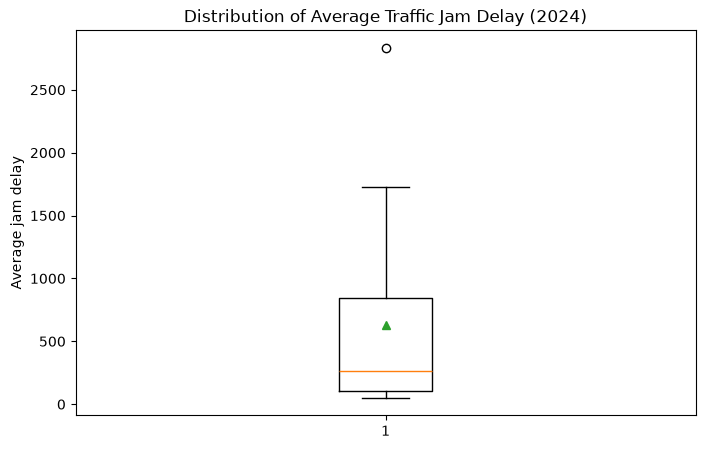

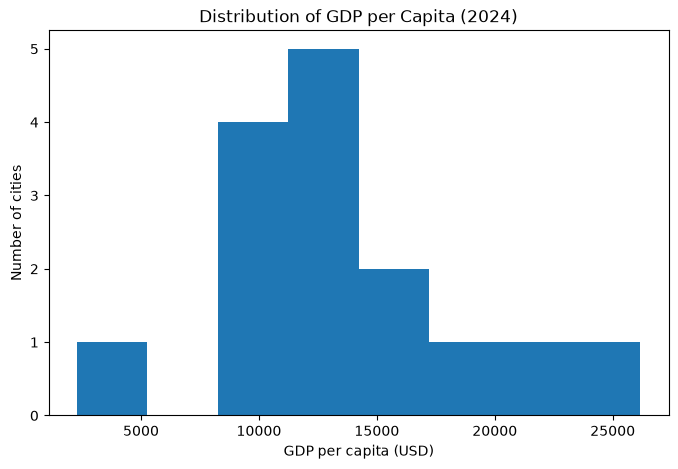

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(merged['jams_delay'], orientation='vertical', showmeans=True)
ax.set_title('Distribution of Average Traffic Jam Delay (2024)')
ax.set_ylabel('Average jam delay')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(merged['city_gdp_capita'], bins=8)
ax.set_title('Distribution of GDP per Capita (2024)')
ax.set_xlabel('GDP per capita (USD)')
ax.set_ylabel('Number of cities')
plt.show()

### GDP per Capita vs. Traffic Congestion

A scatter plot is more appropriate than placing GDP and traffic delay in the same bar chart because the variables use different units and scales.

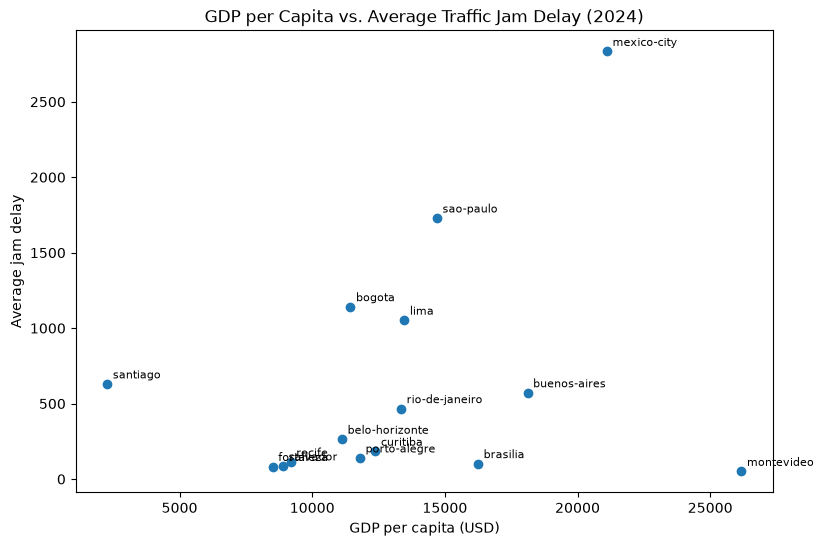

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(merged['city_gdp_capita'], merged['jams_delay'])

for _, row in merged.iterrows():
    ax.annotate(
        row['city'],
        (row['city_gdp_capita'], row['jams_delay']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8
    )

ax.set_title('GDP per Capita vs. Average Traffic Jam Delay (2024)')
ax.set_xlabel('GDP per capita (USD)')
ax.set_ylabel('Average jam delay')
plt.show()

## 6. Association Analysis

In [9]:
association_vars = [
    'jams_delay',
    'city_gdp_capita',
    'unemployment_pct',
    'pm25',
    'population'
]

pearson_corr = merged[association_vars].corr(method='pearson')
spearman_corr = merged[association_vars].corr(method='spearman')

print("Pearson correlations with jams_delay:")
display(
    pearson_corr[['jams_delay']]
    .drop(index='jams_delay')
    .sort_values('jams_delay', key=lambda s: s.abs(), ascending=False)
)

print("Spearman correlations with jams_delay:")
display(
    spearman_corr[['jams_delay']]
    .drop(index='jams_delay')
    .sort_values('jams_delay', key=lambda s: s.abs(), ascending=False)
)

Pearson correlations with jams_delay:


,jams_delay
population,0.878525
pm25,0.767783
unemployment_pct,-0.686956
city_gdp_capita,0.282975


Spearman correlations with jams_delay:


,jams_delay
population,0.864286
pm25,0.803571
unemployment_pct,-0.487936
city_gdp_capita,0.207143


### Interpretation

The correlation coefficients quantify the direction and strength of association within this small cross-sectional sample. With only the cities matched across both sources, these values should be treated as exploratory evidence rather than proof of causality or a basis for claims of statistical significance.

The scatter plot and correlation table should be interpreted together. Cities with similar economic output can still exhibit substantially different congestion levels, suggesting that GDP per capita alone is unlikely to explain urban mobility performance.

## 7. City Comparison

In [10]:
city_comparison = (
    merged[
        ['city', 'country_name', 'jams_delay', 'city_gdp_capita',
         'unemployment_pct', 'pm25', 'population']
    ]
    .sort_values('jams_delay', ascending=False)
    .reset_index(drop=True)
)

display(city_comparison)


,city,country_name,jams_delay,city_gdp_capita,unemployment_pct,pm25,population
0,mexico-city,Mexico,2833.057892,21111.0,3.2,22.3,22100000.0
1,sao-paulo,Brazil,1729.189270,14703.0,8.5,28.0,22600000.0
2,bogota,Colombia,1141.552364,11442.0,10.0,17.6,11300000.0
3,lima,Peru,1052.292789,13472.0,6.5,19.7,11200000.0
4,santiago,Chile,629.865318,2277.0,7.8,21.3,7100000.0
5,buenos-aires,Argentina,571.089593,18117.0,7.2,14.5,15400000.0
6,rio-de-janeiro,Brazil,466.064706,13349.0,9.2,18.4,13700000.0
7,belo-horizonte,Brazil,263.047879,11124.0,9.5,16.8,6100000.0
8,curitiba,Brazil,183.469274,12381.0,8.2,13.5,3700000.0
9,porto-alegre,Brazil,139.382830,11801.0,8.7,14.2,4300000.0


## Key Findings

- Traffic congestion varies substantially across the Latin American cities matched between the two datasets.
- GDP per capita does not, by itself, provide a consistent explanation for differences in congestion.
- Cities with comparable economic indicators can show very different mobility outcomes, pointing to the likely relevance of additional factors such as urban form, transport infrastructure, policy, density, and travel behavior.
- High-congestion cities warrant deeper investigation, but this dataset alone does not establish that congestion causes lower productivity or identify which infrastructure investment would produce the greatest benefit.
- Population, unemployment, and PM2.5 provide useful additional context and can be explored alongside GDP rather than treating economic output as the sole explanatory variable.

## Business / Policy Implications

The analysis is best used as a screening tool for deeper urban-mobility investigation. Cities combining high congestion with challenging socioeconomic or environmental indicators may merit closer study, but investment decisions would require additional evidence such as transport capacity, density, commute patterns, public-transit coverage, infrastructure spending, and longitudinal outcomes.

Rather than ranking cities solely by congestion, a stronger next step would be to develop a multivariable city profile and evaluate changes over time.

## 8. Export Clean Integrated Dataset

In [11]:
merged.to_csv("ladb_mobility_economy_2024.csv", index=False)
print("Saved: ladb_mobility_economy_2024.csv")

Saved: ladb_mobility_economy_2024.csv


## Tools & Skills

- **Python / Pandas:** cleaning, transformation, aggregation, joins, validation, and export
- **Matplotlib:** exploratory visualization
- **Data Integration:** combining high-volume traffic observations with city-level socioeconomic data
- **Exploratory Statistics:** Pearson and Spearman association analysis
- **Urban Analytics:** comparative analysis of mobility, economic, demographic, and environmental indicators
- **Analytical Communication:** translating observed patterns into appropriately scoped findings and next-step recommendations